## **Import Semua Library yang Diperlukan dan Baca Datasets**

**Import Keperluan**

In [ ]:
import numpy as np        # operasi matematika
import pandas as pd       # baca & olah data (tabel)
import tensorflow as tf   # membuat model Compvis
import matplotlib.pyplot as plt  # membuat grafik

print("TensorFlow version:", tf.__version__)  # cek versi tensorflow

TensorFlow version: 2.20.0


**Import ZIP dan Ekstrak**

In [ ]:
from google.colab import files
import zipfile
import os

# Upload file zip
uploaded = files.upload()

# Ekstrak zip
zip_filename = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

print("Ekstrak selesai!")
print("\nStruktur folder:")
for root, dirs, files_list in os.walk('/content/dataset'):
    level = root.replace('/content/dataset', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")

**Baca Datasets dari Folder Data kemudian Langsung Pisahkan untuk Train, Test dan Val**

In [ ]:
from tensorflow.keras.preprocessing import image_dataset_from_directory as IMD

BATCH_SIZE = 32
IMG_HEIGHT = 224
IMG_WIDTH  = 224
SEED       = 42

train_ds = IMD(
    '/content/dataset/data/train',
    image_size=(IMG_HEIGHT, IMG_WIDTH),  # resize nya disini
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=True,
    seed=SEED
)

val_ds = IMD(
    '/content/dataset/data/val',
    image_size=(IMG_HEIGHT, IMG_WIDTH), # resize nya disini
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False,  # val tidak perlu diacak
    seed=SEED
)

test_ds = IMD(
    '/content/dataset/data/test', # resize nya disini
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False,  # test tidak perlu diacak
    seed=SEED
)

print("Class names:", train_ds.class_names)
print(f"Train batches : {len(train_ds)}")
print(f"Val batches   : {len(val_ds)}")
print(f"Test batches  : {len(test_ds)}")

Found 791 files belonging to 2 classes.
Found 98 files belonging to 2 classes.
Found 100 files belonging to 2 classes.
Class names: ['Accident', 'Non Accident']
Train batches : 25
Val batches   : 4
Test batches  : 4


**Lihat Contoh Gambar untuk Masing Masing Label per Datasets**

In [ ]:
def show_one_per_class(dataset, dataset_name):
    class_names = dataset.class_names
    shown_labels = set()

    plt.figure(figsize=(8, 4))
    plot_idx = 1

    for images, labels in dataset:
        for i in range(len(images)):
            label = int(float(labels[i].numpy()[0]))
            if label not in shown_labels:
                plt.subplot(1, len(class_names), plot_idx)
                plt.imshow(images[i].numpy().astype("uint8"))
                plt.title(class_names[label])
                plt.axis("off")

                shown_labels.add(label)
                plot_idx += 1

            if len(shown_labels) == len(class_names):
                break

        if len(shown_labels) == len(class_names):
            break

    plt.suptitle(f"Contoh Gambar per Label - {dataset_name}")
    plt.tight_layout()
    plt.show()

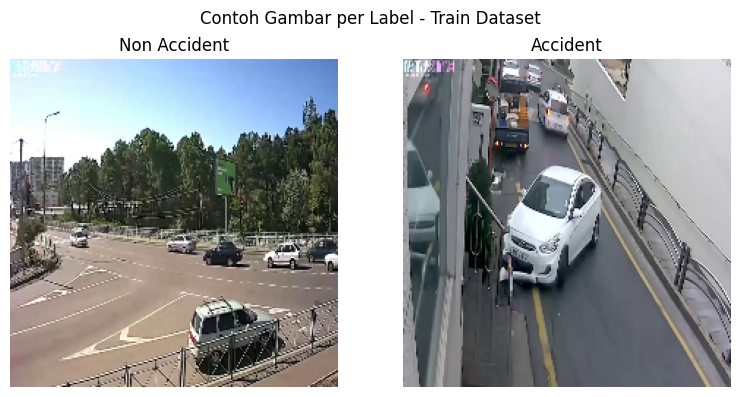

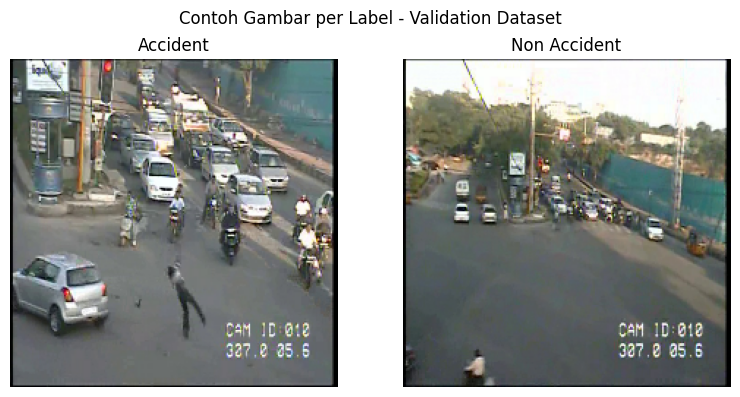

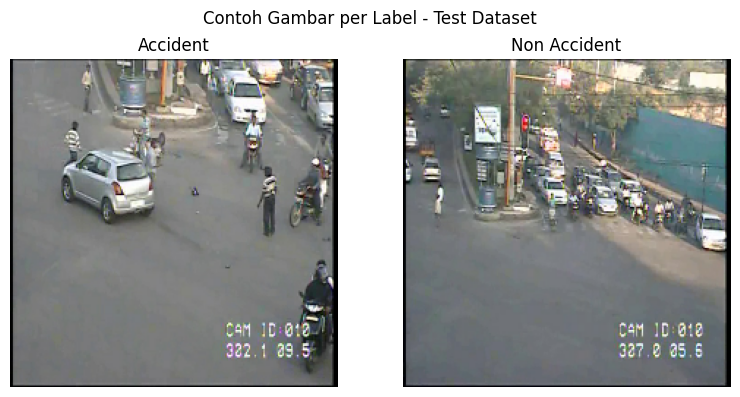

In [ ]:
show_one_per_class(train_ds, "Train Dataset")
show_one_per_class(val_ds, "Validation Dataset")
show_one_per_class(test_ds, "Test Dataset")

In [ ]:
for images, labels in train_ds.take(1):
    print(labels[0])
    print(labels[0].numpy())

tf.Tensor([0.], shape=(1,), dtype=float32)
[0.]


## **Prepocessing Datanya yang Sudah di Baca Tadi**

**Normalisasi Gambarnya**

In [ ]:
nomralization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (nomralization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (nomralization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (nomralization_layer(x), y))

## **Model dan Juga Training**

**Buat Model CNN**

In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,244,929 (84.86 MB)

 Trainable params: 22,244,929 (84.86 MB)

 Non-trainable params: 0 (0.00 B)

**Training Modelnya Menggunakan Datasets yang sudah di Proses Sebelumnya**

In [ ]:
tf.random.set_seed(42)

history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=10
)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 346ms/step - accuracy: 0.5613 - loss: 0.7980 - val_accuracy: 0.5816 - val_loss: 0.6483
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 264ms/step - accuracy: 0.6713 - loss: 0.6162 - val_accuracy: 0.6531 - val_loss: 0.6048
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 240ms/step - accuracy: 0.7219 - loss: 0.5531 - val_accuracy: 0.7551 - val_loss: 0.5616
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 152ms/step - accuracy: 0.7699 - loss: 0.4965 - val_accuracy: 0.8673 - val_loss: 0.4164
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 159ms/step - accuracy: 0.8003 - loss: 0.4176 - val_accuracy: 0.8776 - val_loss: 0.3119
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 167ms/step - accuracy: 0.8748 - loss: 0.3067 - val_accuracy: 0.8163 - val_loss: 0.4054
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 154ms/step - accuracy: 0.8887 - loss: 0.2548 - val_accuracy: 0.9184 - val_loss: 0.2346
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 223ms/step - accuracy: 0.9128 - loss: 0.2290 - val_accuracy: 

**Grafik Validation untuk Melihat Hasil Model**

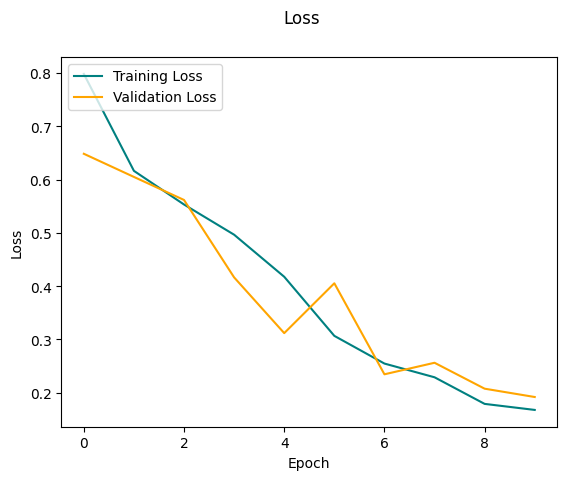

In [ ]:
fig = plt.figure()
plt.plot(history.history['loss'], color='teal', label='Training Loss')
plt.plot(history.history['val_loss'], color='orange', label='Validation Loss')
fig.suptitle('Loss')
plt.legend(loc="upper left")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

**Skor Model**

In [ ]:
pip install scikit-learn

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy().flatten())
    y_pred.extend((predictions > 0.5).astype(int).flatten())

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

Accuracy  : 0.8800
Precision : 0.8596
Recall    : 0.9245
F1 Score  : 0.8909


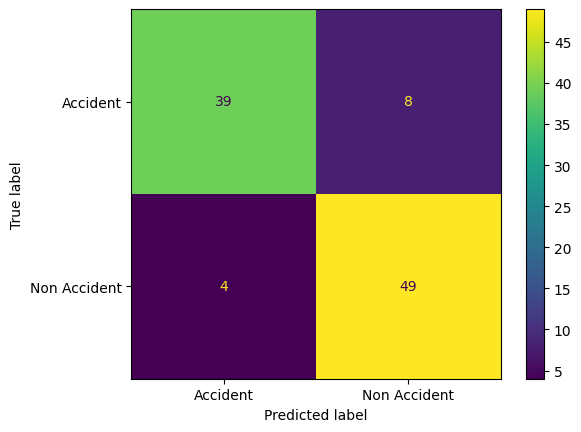

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Accident', 'Non Accident']
)

disp.plot()
plt.show()

**Testing Model menggunakan Datasets Test yang sudah Dipisah Sebelumnya**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step


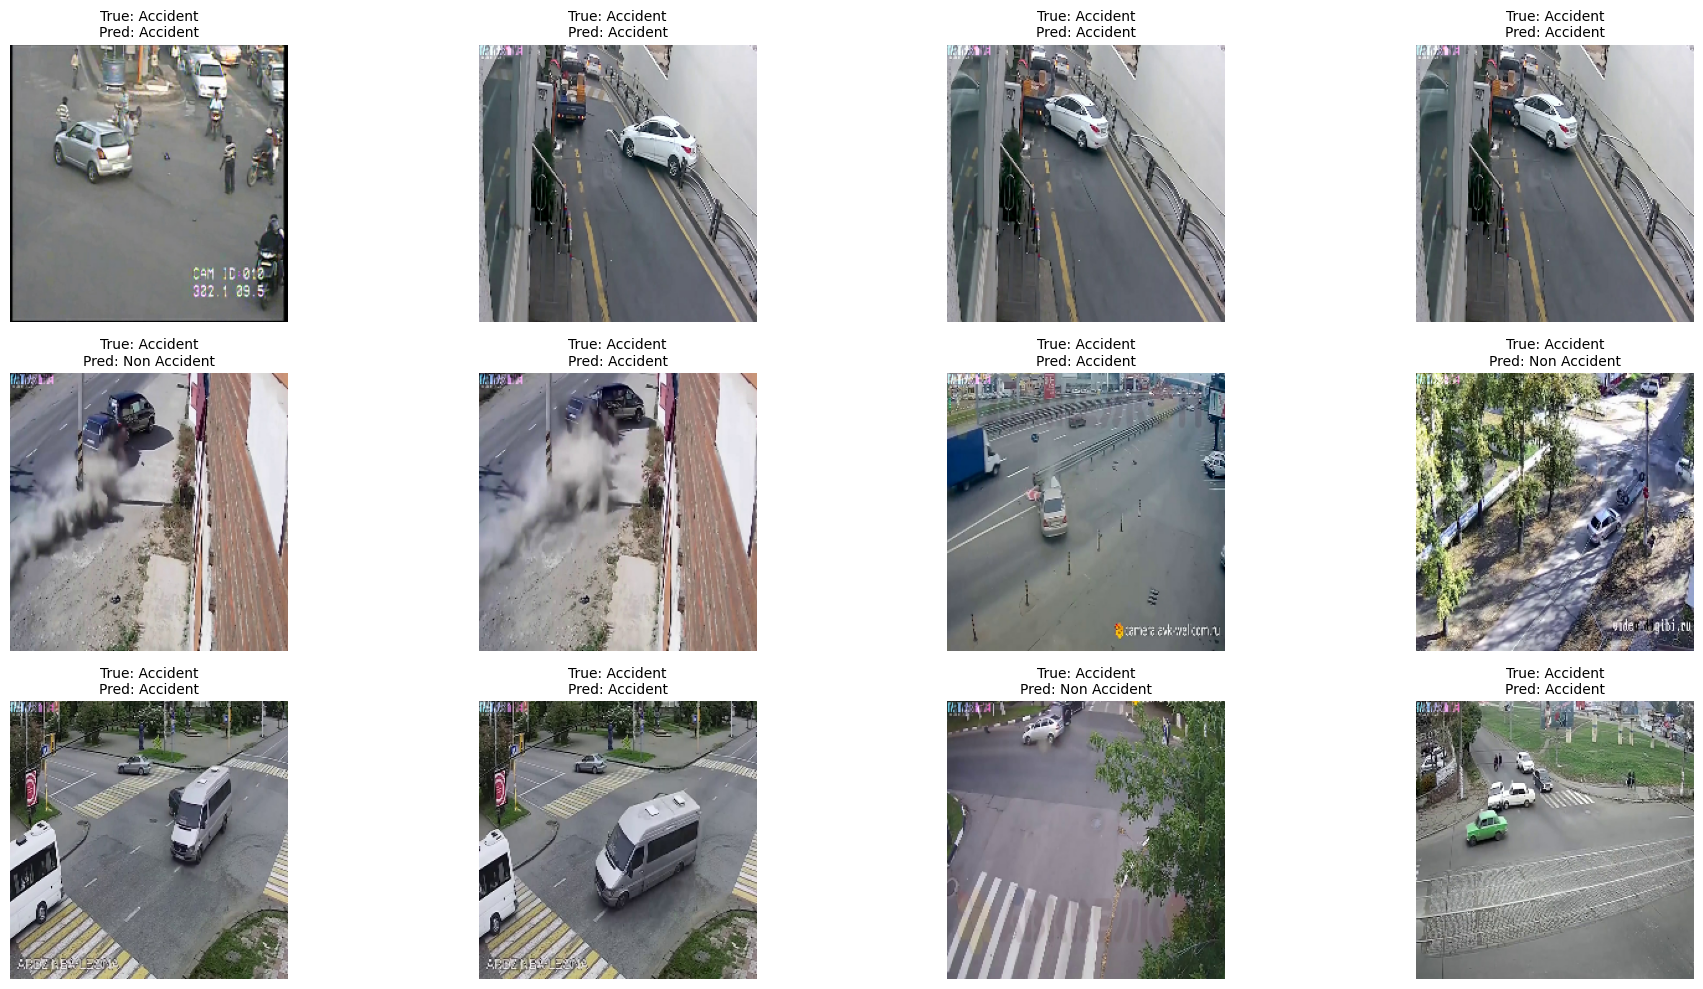

In [ ]:
class_names = ['Accident', 'Non Accident']

for images, labels in test_ds.take(1):
    predictions = model.predict(images)
    plt.figure(figsize=(20, 10))
    for i in range(min(len(images), 12)):
        ax = plt.subplot(3, 4, i + 1)
        img = (images[i].numpy() * 255).astype("uint8")
        plt.imshow(img)
        true_label = class_names[int(labels[i].numpy()[0])]
        pred_label = class_names[int(predictions[i][0] > 0.5)]
        plt.title(
            f"True: {true_label}\nPred: {pred_label}",
            fontsize=10
        )
        plt.axis("off")
    plt.tight_layout()
    plt.show()

**Import Menjadi Pickle**

In [ ]:
model.save('accident_model.keras')